In [6]:
# Install if needed
# !pip install scikit-learn pandas matplotlib seaborn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [7]:
df = pd.read_csv("housing.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (76038, 9)


,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [8]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Null Values ===")
print(df.isnull().sum())
print("\n=== Value Counts: price_unit ===")
print(df['price_unit'].value_counts())

=== Data Types ===
bhk             int64
type           object
locality       object
area            int64
price         float64
price_unit     object
region         object
status         object
age            object
dtype: object

=== Null Values ===
bhk           0
type          0
locality      0
area          0
price         0
price_unit    0
region        0
status        0
age           0
dtype: int64

=== Value Counts: price_unit ===
price_unit
Cr    40981
L     35057
Name: count, dtype: int64


In [9]:
df['price_in_lakhs'] = df.apply(
    lambda row: row['price'] * 100 if row['price_unit'] == 'Cr' else row['price'],
    axis=1
)

print("Price range (in Lakhs):")
print(df['price_in_lakhs'].describe())

Price range (in Lakhs):
count    76038.000000
mean       168.417795
std        217.665511
min          4.490000
25%         64.000000
50%        110.000000
75%        194.000000
max       6000.000000
Name: price_in_lakhs, dtype: float64


In [10]:
# Remove extreme outliers using IQR
Q1 = df['price_in_lakhs'].quantile(0.01)
Q3 = df['price_in_lakhs'].quantile(0.99)
df = df[(df['price_in_lakhs'] >= Q1) & (df['price_in_lakhs'] <= Q3)]

# Also remove unrealistic areas
df = df[(df['area'] >= 100) & (df['area'] <= 10000)]

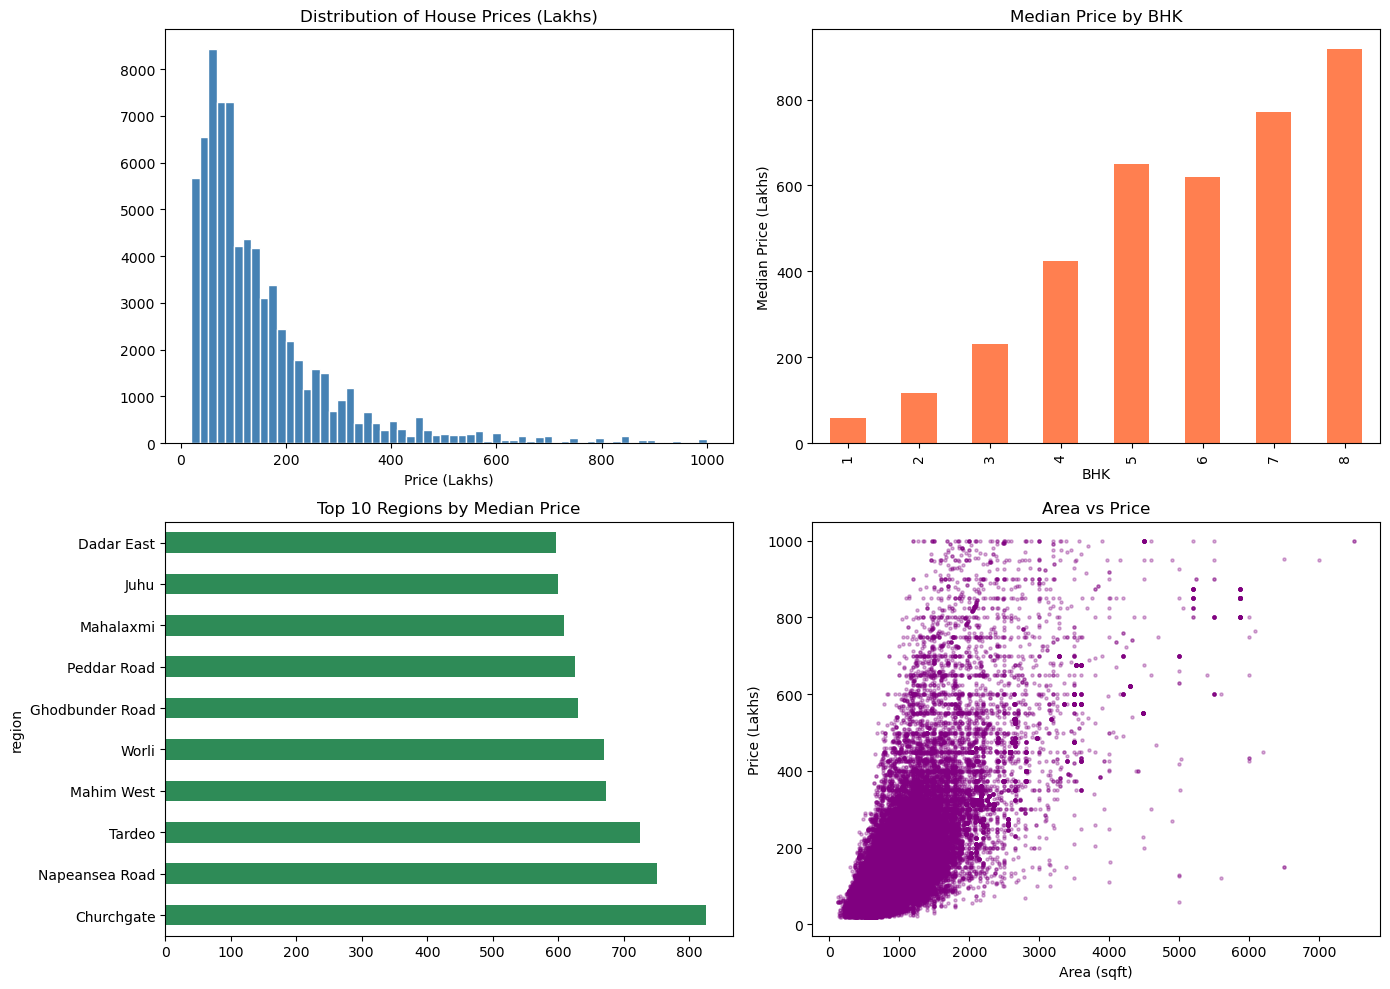

✅ EDA plots rendered


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price Distribution
axes[0, 0].hist(df['price_in_lakhs'], bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of House Prices (Lakhs)')
axes[0, 0].set_xlabel('Price (Lakhs)')

# 2. BHK vs Price
df.groupby('bhk')['price_in_lakhs'].median().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Median Price by BHK')
axes[0, 1].set_xlabel('BHK')
axes[0, 1].set_ylabel('Median Price (Lakhs)')

# 3. Top 10 Expensive Regions
top_regions = df.groupby('region')['price_in_lakhs'].median().nlargest(10)
top_regions.plot(kind='barh', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Top 10 Regions by Median Price')

# 4. Area vs Price
axes[1, 1].scatter(df['area'], df['price_in_lakhs'], alpha=0.3, color='purple', s=5)
axes[1, 1].set_title('Area vs Price')
axes[1, 1].set_xlabel('Area (sqft)')
axes[1, 1].set_ylabel('Price (Lakhs)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print("✅ EDA plots rendered")

In [12]:
# Price per sqft
df['price_per_sqft'] = df['price_in_lakhs'] / df['area']

# Encode categorical features
le = LabelEncoder()
df['region_encoded']  = le.fit_transform(df['region'])
df['type_encoded']    = le.fit_transform(df['type'])
df['status_encoded']  = le.fit_transform(df['status'])
df['age_encoded']     = le.fit_transform(df['age'])

# Region-level average price (target encoding)
region_avg = df.groupby('region')['price_in_lakhs'].mean()
df['region_avg_price'] = df['region'].map(region_avg)

print("Features after engineering:")
print(df[['bhk', 'area', 'price_per_sqft', 'region_encoded', 
          'type_encoded', 'status_encoded', 'age_encoded', 
          'region_avg_price', 'price_in_lakhs']].head())

Features after engineering:
   bhk  area  price_per_sqft  region_encoded  type_encoded  status_encoded  \
0    3   685        0.364964               8             0               0   
1    2   640        0.082047             117             0               1   
2    2   610        0.283607              28             0               1   
3    2   876        0.068470             133             0               1   
4    2   659        0.142807             111             0               1   

   age_encoded  region_avg_price  price_in_lakhs  
0            0        264.465420          250.00  
1            0         38.613950           52.51  
2            0        211.395800          173.00  
3            0         86.667772           59.98  
4            0         81.426644           94.11  


In [13]:
features = ['bhk', 'area', 'region_encoded', 'type_encoded', 
            'status_encoded', 'age_encoded', 'region_avg_price']

X = df[features]
y = df['price_in_lakhs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 59653
Testing  samples : 14914


In [14]:
models = {
    "Linear Regression"       : LinearRegression(),
    "Random Forest"           : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting"       : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    X_tr = X_train_sc if name == "Linear Regression" else X_train
    X_te = X_test_sc  if name == "Linear Regression" else X_test
    
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"\n📊 {name}")
    print(f"   MAE  : ₹{mae:.2f} Lakhs")
    print(f"   RMSE : ₹{rmse:.2f} Lakhs")
    print(f"   R²   : {r2:.4f}")


📊 Linear Regression
   MAE  : ₹43.40 Lakhs
   RMSE : ₹64.93 Lakhs
   R²   : 0.7964

📊 Random Forest
   MAE  : ₹20.21 Lakhs
   RMSE : ₹41.87 Lakhs
   R²   : 0.9153

📊 Gradient Boosting
   MAE  : ₹28.17 Lakhs
   RMSE : ₹49.38 Lakhs
   R²   : 0.8822


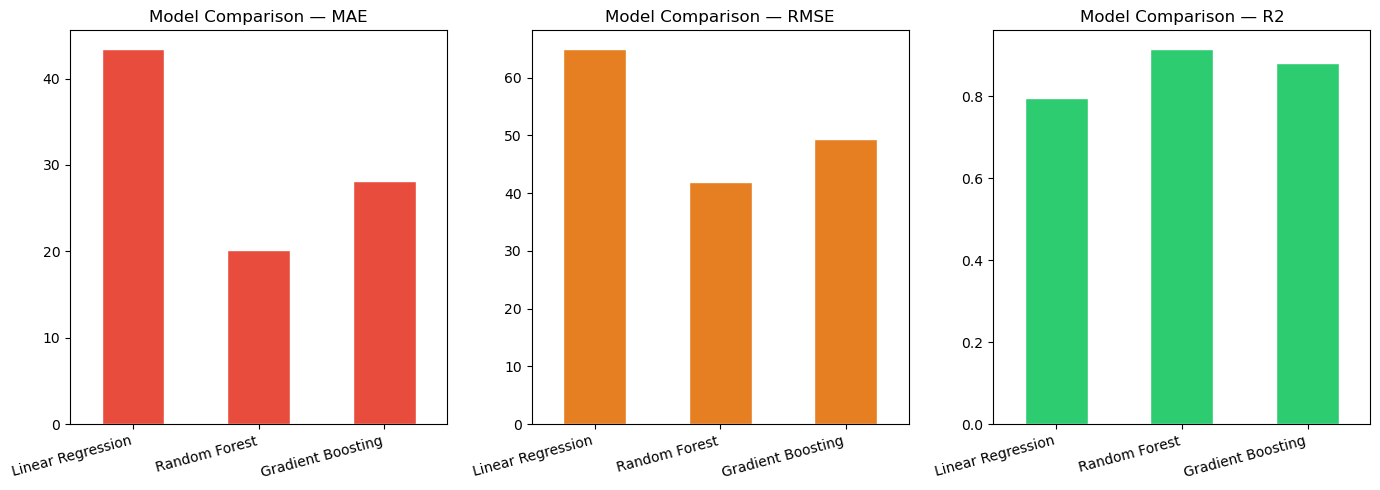

In [15]:
res_df = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#e74c3c', '#e67e22', '#2ecc71']

for i, metric in enumerate(metrics):
    res_df[metric].plot(kind='bar', ax=axes[i], color=colors[i], edgecolor='white')
    axes[i].set_title(f'Model Comparison — {metric}')
    axes[i].set_xticklabels(res_df.index, rotation=15, ha='right')

plt.tight_layout()
plt.show()

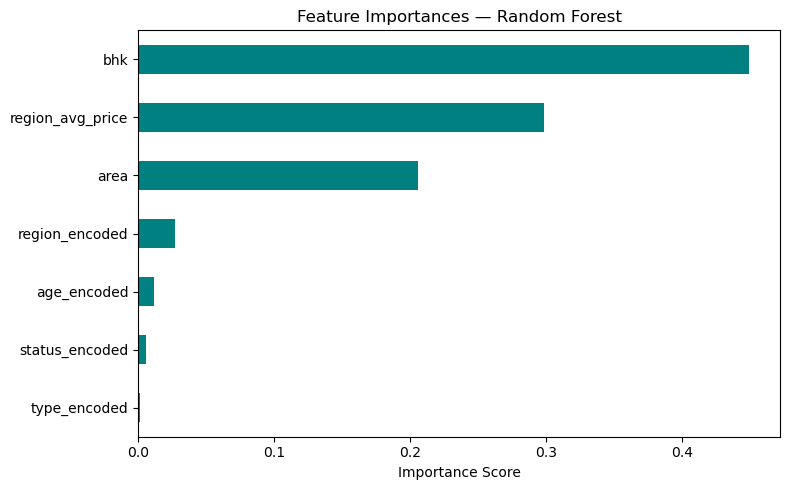

In [16]:
best_model = models["Random Forest"]

importances = pd.Series(
    best_model.feature_importances_, index=features
).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), color='teal')
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

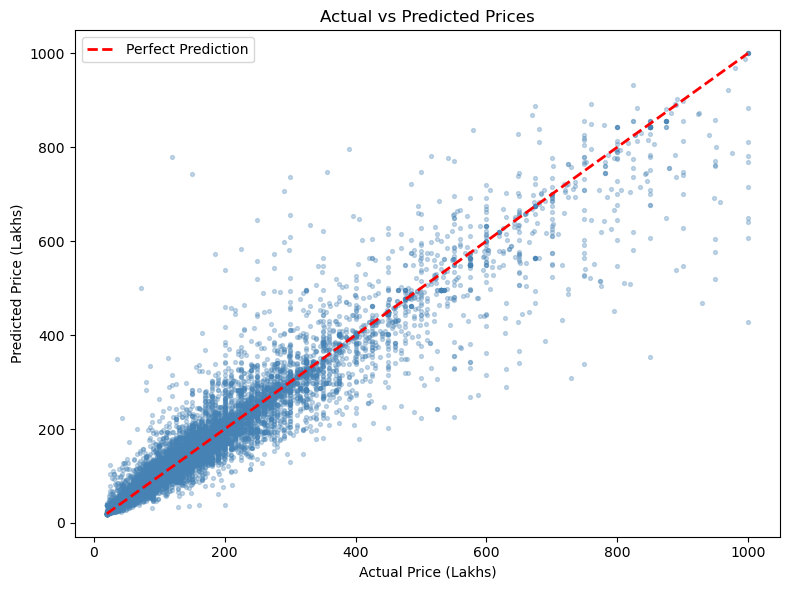

In [17]:
preds = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.3, s=8, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Mapping helper (run once)
region_to_encoded  = dict(zip(df['region'], df['region_encoded']))
region_to_avg      = dict(zip(df['region'], df['region_avg_price']))
type_to_encoded    = dict(zip(df['type'],   df['type_encoded']))
status_to_encoded  = dict(zip(df['status'], df['status_encoded']))
age_to_encoded     = dict(zip(df['age'],    df['age_encoded']))

def predict_price(bhk, area, region, prop_type="Apartment",
                  status="Ready to move", age="New"):
    """Predict house price in Lakhs for given property details."""
    
    if region not in region_to_encoded:
        print(f"⚠️  Region '{region}' not found in training data.")
        return None
    
    input_data = pd.DataFrame([{
        'bhk'             : bhk,
        'area'            : area,
        'region_encoded'  : region_to_encoded[region],
        'type_encoded'    : type_to_encoded.get(prop_type, 0),
        'status_encoded'  : status_to_encoded.get(status, 0),
        'age_encoded'     : age_to_encoded.get(age, 0),
        'region_avg_price': region_to_avg[region]
    }])
    
    price = best_model.predict(input_data)[0]
    print(f"\n🏠 Property Details:")
    print(f"   Region : {region}")
    print(f"   BHK    : {bhk} | Area: {area} sqft | Type: {prop_type}")
    print(f"   Status : {status} | Age: {age}")
    print(f"\n💰 Predicted Price : ₹{price:.2f} Lakhs  (~₹{price/100:.2f} Cr)")
    return price

# --- Example Predictions ---
predict_price(bhk=2, area=700, region="Andheri West")
predict_price(bhk=3, area=1200, region="Powai", status="Under Construction")
predict_price(bhk=2, area=750, region="Thane West", age="Resale")


🏠 Property Details:
   Region : Andheri West
   BHK    : 2 | Area: 700 sqft | Type: Apartment
   Status : Ready to move | Age: New

💰 Predicted Price : ₹180.36 Lakhs  (~₹1.80 Cr)

🏠 Property Details:
   Region : Powai
   BHK    : 3 | Area: 1200 sqft | Type: Apartment
   Status : Under Construction | Age: New

💰 Predicted Price : ₹360.64 Lakhs  (~₹3.61 Cr)

🏠 Property Details:
   Region : Thane West
   BHK    : 2 | Area: 750 sqft | Type: Apartment
   Status : Ready to move | Age: Resale

💰 Predicted Price : ₹98.26 Lakhs  (~₹0.98 Cr)


np.float64(98.261029503683)